# Single-run LightGBM confidence diagnostics

This notebook analyzes one archived annotated `.h5ad` file from the LightGBM pipeline. It focuses on per-cell confidence, normalized entropy, margin, wrong predictions, and their overlap.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


## Load one archived run

Change `target_path` if you want to inspect a different dataset or Leiden resolution.

In [21]:
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

target_path = project_root / "data/processed/archive/pbmc3k_res_2p5.h5ad"

adata = sc.read_h5ad(target_path)
adata


AnnData object with n_obs Ã— n_vars = 2700 Ã— 2000
    obs: 'leiden', 'oof_fold_lgbm', 'predicted_cluster_lgbm', 'confidence_lgbm', 'entropy_lgbm', 'margin_lgbm', 'entropy_norm_lgbm', 'prediction_matches_leiden', 'low_confidence_lgbm'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'pipeline_params', 'probs_lgbm_columns', 'probs_lgbm_source', 'umap'
    obsm: 'X_pca', 'X_umap', 'probs_lgbm'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [22]:
print("obs columns:")
print(list(adata.obs.columns))

print("\nobsm keys:")
print(list(adata.obsm.keys()))

print("\nuns keys:")
print(list(adata.uns.keys()))


obs columns:
['leiden', 'oof_fold_lgbm', 'predicted_cluster_lgbm', 'confidence_lgbm', 'entropy_lgbm', 'margin_lgbm', 'entropy_norm_lgbm', 'prediction_matches_leiden', 'low_confidence_lgbm']

obsm keys:
['X_pca', 'X_umap', 'probs_lgbm']

uns keys:
['hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'pipeline_params', 'probs_lgbm_columns', 'probs_lgbm_source', 'umap']


## Per-cell metadata and probabilities

In [23]:
obs = adata.obs.copy()

if "entropy_norm_lgbm" not in obs:
    n_classes = obs["leiden"].astype(str).nunique()
    obs["entropy_norm_lgbm"] = obs["entropy_lgbm"] / np.log(n_classes)

metric_cols = [
    "leiden",
    "predicted_cluster_lgbm",
    "confidence_lgbm",
    "entropy_lgbm",
    "entropy_norm_lgbm",
    "margin_lgbm",
    "prediction_matches_leiden",
    "low_confidence_lgbm",
]

available_metric_cols = [col for col in metric_cols if col in obs]
obs[available_metric_cols].head()


,leiden,predicted_cluster_lgbm,confidence_lgbm,entropy_lgbm,entropy_norm_lgbm,margin_lgbm,prediction_matches_leiden,low_confidence_lgbm
index,,,,,,,,
AAACATACAACCAC-1,2,2,0.988995,0.069840,0.022274,0.980455,True,False
AAACATTGAGCTAC-1,0,0,0.999999,0.000014,0.000004,0.999999,True,False
AAACATTGATCAGC-1,7,11,0.734582,0.707848,0.225753,0.498806,False,False
AAACCGTGCTTCCG-1,3,3,0.999847,0.001794,0.000572,0.999763,True,False
AAACCGTGTATGCG-1,5,5,0.999801,0.002005,0.000640,0.999620,True,False


In [24]:
if "probs_lgbm" not in adata.obsm:
    raise KeyError("adata.obsm['probs_lgbm'] is not available in this file.")

classes = adata.uns.get("probs_lgbm_columns")
if classes is None:
    classes = [str(i) for i in range(adata.obsm["probs_lgbm"].shape[1])]

probs_df = pd.DataFrame(
    adata.obsm["probs_lgbm"],
    index=adata.obs_names,
    columns=[f"prob_cluster_{c}" for c in classes],
)

obs_with_probs = obs.join(probs_df)
obs_with_probs.head()


,leiden,oof_fold_lgbm,predicted_cluster_lgbm,confidence_lgbm,entropy_lgbm,margin_lgbm,entropy_norm_lgbm,prediction_matches_leiden,low_confidence_lgbm,prob_cluster_0,...,prob_cluster_20,prob_cluster_21,prob_cluster_22,prob_cluster_3,prob_cluster_4,prob_cluster_5,prob_cluster_6,prob_cluster_7,prob_cluster_8,prob_cluster_9
index,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,2,2,2,0.988995,0.069840,0.980455,0.022274,True,False,8.106878e-06,...,3.668929e-06,3.562978e-06,5.592672e-06,1.188306e-05,1.074513e-03,1.620145e-05,5.528072e-06,1.405261e-04,5.151311e-06,4.740411e-06
AAACATTGAGCTAC-1,0,1,0,0.999999,0.000014,0.999999,0.000004,True,False,9.999992e-01,...,7.514896e-08,1.225938e-08,1.027163e-08,5.270613e-08,1.794004e-08,1.999626e-08,5.611684e-08,6.908811e-08,6.838428e-08,2.549154e-08
AAACATTGATCAGC-1,7,3,11,0.734582,0.707848,0.498806,0.225753,False,False,1.343501e-04,...,1.756421e-03,8.130257e-05,1.570868e-04,5.916781e-05,1.290169e-04,1.058811e-04,1.689039e-04,2.357765e-01,6.999178e-05,2.138067e-02
AAACCGTGCTTCCG-1,3,1,3,0.999847,0.001794,0.999763,0.000572,True,False,2.706091e-06,...,1.579960e-06,1.128265e-06,1.553659e-06,9.998473e-01,4.913532e-06,1.806151e-06,8.415826e-05,7.653800e-06,7.969636e-06,3.164562e-06
AAACCGTGTATGCG-1,5,1,5,0.999801,0.002005,0.999620,0.000640,True,False,8.998838e-07,...,1.307687e-06,1.148151e-06,6.197980e-08,4.129167e-07,3.553348e-06,9.998009e-01,1.672990e-07,1.201911e-06,1.804366e-04,1.505802e-07


## Percentiles

In [25]:
percentile_rows = []

for metric, qs in {
    "margin_lgbm": [0.50, 0.30, 0.10, 0.05, 0.01],
    "entropy_norm_lgbm": [0.50, 0.70, 0.90, 0.95, 0.99],
    "confidence_lgbm": [0.50, 0.30, 0.10, 0.05, 0.01],
}.items():
    values = obs[metric].quantile(qs)
    for q, value in values.items():
        percentile_rows.append({
            "metric": metric,
            "percentile": f"p{int(q * 100)}",
            "value": value,
        })

percentile_df = pd.DataFrame(percentile_rows)
percentile_df


,metric,percentile,value
0,margin_lgbm,p50,0.996543
1,margin_lgbm,p30,0.820354
2,margin_lgbm,p10,0.271000
3,margin_lgbm,p5,0.115682
4,margin_lgbm,p1,0.026204
5,entropy_norm_lgbm,p50,0.005260
6,entropy_norm_lgbm,p70,0.141834
7,entropy_norm_lgbm,p90,0.415991
8,entropy_norm_lgbm,p95,0.502153
9,entropy_norm_lgbm,p99,0.660416


## Wrong predictions and uncertainty-tail overlap

Set `tail_fraction` to `0.02`, `0.05`, `0.10`, etc. to compare stricter or looser uncertainty tails.

In [26]:
tail_fraction = 0.05

wrong_mask = (
    obs["predicted_cluster_lgbm"].astype(str)
    != obs["leiden"].astype(str)
)

low_margin_cutoff = obs["margin_lgbm"].quantile(tail_fraction)
high_entropy_cutoff = obs["entropy_norm_lgbm"].quantile(1 - tail_fraction)
low_conf_cutoff = obs["confidence_lgbm"].quantile(tail_fraction)

low_margin_mask = obs["margin_lgbm"] <= low_margin_cutoff
high_entropy_mask = obs["entropy_norm_lgbm"] >= high_entropy_cutoff
low_conf_mask = obs["confidence_lgbm"] <= low_conf_cutoff
uncertain_mask = low_margin_mask | high_entropy_mask | low_conf_mask

cutoffs = pd.Series({
    "tail_fraction": tail_fraction,
    "low_margin_cutoff": low_margin_cutoff,
    "high_entropy_cutoff": high_entropy_cutoff,
    "low_confidence_cutoff": low_conf_cutoff,
})

cutoffs


tail_fraction            0.050000
low_margin_cutoff        0.115682
high_entropy_cutoff      0.502153
low_confidence_cutoff    0.426653
dtype: float64

In [27]:
overlap_summary = pd.DataFrame({
    "group": [
        "wrong_prediction",
        "low_margin_tail",
        "high_entropy_tail",
        "low_confidence_tail",
        "any_uncertainty_tail",
        "wrong & low_margin",
        "wrong & high_entropy",
        "wrong & low_confidence",
        "wrong & any_uncertainty",
        "low_margin & high_entropy",
        "low_margin & low_confidence",
        "high_entropy & low_confidence",
        "wrong & all_three_uncertainty",
    ],
    "n_cells": [
        wrong_mask.sum(),
        low_margin_mask.sum(),
        high_entropy_mask.sum(),
        low_conf_mask.sum(),
        uncertain_mask.sum(),
        (wrong_mask & low_margin_mask).sum(),
        (wrong_mask & high_entropy_mask).sum(),
        (wrong_mask & low_conf_mask).sum(),
        (wrong_mask & uncertain_mask).sum(),
        (low_margin_mask & high_entropy_mask).sum(),
        (low_margin_mask & low_conf_mask).sum(),
        (high_entropy_mask & low_conf_mask).sum(),
        (wrong_mask & low_margin_mask & high_entropy_mask & low_conf_mask).sum(),
    ],
})

overlap_summary["fraction_of_cells"] = overlap_summary["n_cells"] / adata.n_obs
overlap_summary


,group,n_cells,fraction_of_cells
0,wrong_prediction,674,0.249630
1,low_margin_tail,135,0.050000
2,high_entropy_tail,135,0.050000
3,low_confidence_tail,135,0.050000
4,any_uncertainty_tail,212,0.078519
5,wrong & low_margin,99,0.036667
6,wrong & high_entropy,95,0.035185
7,wrong & low_confidence,102,0.037778
8,wrong & any_uncertainty,152,0.056296
9,low_margin & high_entropy,66,0.024444


## Inspect wrong predictions

In [28]:
wrong_with_probs = obs_with_probs.loc[wrong_mask].copy()

display_cols = [
    "leiden",
    "predicted_cluster_lgbm",
    "confidence_lgbm",
    "entropy_norm_lgbm",
    "margin_lgbm",
] + list(probs_df.columns)

wrong_with_probs[display_cols].sort_values("confidence_lgbm", ascending=True)


,leiden,predicted_cluster_lgbm,confidence_lgbm,entropy_norm_lgbm,margin_lgbm,prob_cluster_0,prob_cluster_1,prob_cluster_10,prob_cluster_11,prob_cluster_12,...,prob_cluster_20,prob_cluster_21,prob_cluster_22,prob_cluster_3,prob_cluster_4,prob_cluster_5,prob_cluster_6,prob_cluster_7,prob_cluster_8,prob_cluster_9
index,,,,,,,,,,,,,,,,,,,,,
GACAACTGAGGTTC-1,16,11,0.170864,0.746929,0.001691,5.902337e-03,4.796505e-03,8.640540e-03,1.708642e-01,1.666744e-01,...,1.025959e-02,2.321815e-03,2.724632e-03,5.586024e-03,1.179044e-02,9.482872e-03,3.921312e-03,1.253739e-01,4.124352e-03,1.691736e-01
AGAAAGTGCGCAAT-1,4,7,0.196524,0.710192,0.038649,2.750200e-03,2.625015e-03,1.576149e-01,2.383934e-02,1.261762e-01,...,1.322277e-03,1.220751e-03,4.844825e-03,1.995397e-03,8.068003e-02,3.669047e-03,2.335736e-03,1.965239e-01,2.074979e-03,1.261804e-01
ACAACCGAGTTACG-1,9,14,0.203614,0.707680,0.010845,2.933306e-03,1.649214e-03,8.912702e-03,9.705985e-02,2.685644e-02,...,1.537856e-03,8.466261e-04,3.288654e-03,2.007704e-03,3.411270e-02,1.780128e-03,2.352939e-03,1.678182e-01,1.216789e-03,5.543912e-02
GCGGAGCTCCTGAA-1,4,7,0.214070,0.712479,0.052118,2.181598e-03,3.055382e-03,5.749209e-02,1.619513e-01,4.568302e-02,...,9.483643e-04,1.441753e-03,1.959101e-03,1.878574e-03,1.288372e-01,1.839314e-03,1.312244e-03,2.140695e-01,1.364193e-03,1.279595e-02
GGAACTACTACTTC-1,15,9,0.214731,0.624775,0.008765,1.646368e-03,1.350851e-03,7.341028e-03,1.577982e-01,2.059656e-01,...,6.005184e-04,7.088553e-04,1.116821e-03,7.319604e-04,9.621036e-03,1.010290e-03,1.056742e-03,1.639666e-02,8.700859e-04,2.147306e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGCGGACTCTTGGA-1,2,8,0.999956,0.000162,0.999917,3.160092e-07,1.756989e-07,2.153233e-07,1.195251e-07,3.289252e-07,...,7.262932e-08,3.862949e-08,6.894674e-08,1.214716e-07,3.061282e-07,5.855329e-07,7.264645e-08,1.095938e-06,9.999562e-01,8.019198e-08
TTGCATTGCTAAGC-1,3,1,0.999965,0.000135,0.999935,1.396899e-07,9.999650e-01,2.530318e-07,7.851957e-08,5.278958e-07,...,2.275786e-07,2.609859e-07,8.108102e-08,2.989412e-05,3.864087e-07,1.521823e-07,1.300111e-07,2.648048e-07,8.235376e-08,1.201835e-07
CATGCGCTCAGATC-1,3,1,0.999979,0.000086,0.999961,9.647677e-08,9.999786e-01,1.082618e-07,7.423569e-08,4.469910e-07,...,4.681365e-08,4.508582e-08,4.625474e-08,1.777618e-05,9.114717e-08,6.733747e-08,6.414654e-08,5.535093e-07,6.439667e-08,2.178470e-07


In [29]:
wrong_confident = obs_with_probs.loc[wrong_mask & ~uncertain_mask].copy()

wrong_confident[display_cols].sort_values("confidence_lgbm", ascending=False)


,leiden,predicted_cluster_lgbm,confidence_lgbm,entropy_norm_lgbm,margin_lgbm,prob_cluster_0,prob_cluster_1,prob_cluster_10,prob_cluster_11,prob_cluster_12,...,prob_cluster_20,prob_cluster_21,prob_cluster_22,prob_cluster_3,prob_cluster_4,prob_cluster_5,prob_cluster_6,prob_cluster_7,prob_cluster_8,prob_cluster_9
index,,,,,,,,,,,,,,,,,,,,,
CGAGGCTGGCAGTT-1,1,3,0.999993,0.000035,0.999989,1.805550e-07,3.989404e-06,2.023026e-07,4.345390e-07,2.348808e-07,...,4.768757e-07,9.028405e-08,1.199550e-07,9.999926e-01,1.472040e-07,9.269546e-08,8.026445e-08,1.926321e-07,6.638593e-08,5.525763e-08
ATGGACACGCATCA-1,8,5,0.999980,0.000083,0.999968,3.076036e-07,1.242601e-07,7.589983e-08,7.395952e-08,1.022633e-07,...,3.811217e-08,1.809001e-08,1.815064e-08,3.442385e-08,3.220532e-07,9.999803e-01,3.366827e-08,3.443545e-08,1.272534e-05,4.232559e-08
CATGCGCTCAGATC-1,3,1,0.999979,0.000086,0.999961,9.647677e-08,9.999786e-01,1.082618e-07,7.423569e-08,4.469910e-07,...,4.681365e-08,4.508582e-08,4.625474e-08,1.777618e-05,9.114717e-08,6.733747e-08,6.414654e-08,5.535093e-07,6.439667e-08,2.178470e-07
TTGCATTGCTAAGC-1,3,1,0.999965,0.000135,0.999935,1.396899e-07,9.999650e-01,2.530318e-07,7.851957e-08,5.278958e-07,...,2.275786e-07,2.609859e-07,8.108102e-08,2.989412e-05,3.864087e-07,1.521823e-07,1.300111e-07,2.648048e-07,8.235376e-08,1.201835e-07
GGCGGACTCTTGGA-1,2,8,0.999956,0.000162,0.999917,3.160092e-07,1.756989e-07,2.153233e-07,1.195251e-07,3.289252e-07,...,7.262932e-08,3.862949e-08,6.894674e-08,1.214716e-07,3.061282e-07,5.855329e-07,7.264645e-08,1.095938e-06,9.999562e-01,8.019198e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATGCTTTGCGAATC-1,10,15,0.450295,0.461962,0.190075,5.569790e-04,5.620002e-04,1.620441e-01,7.903841e-02,3.840183e-04,...,2.191069e-04,2.233590e-04,2.733066e-04,6.919620e-04,2.602204e-01,4.237638e-04,3.589531e-04,1.442648e-02,6.248583e-04,9.106563e-03
TGACCAGAGGATTC-1,13,4,0.446318,0.381787,0.146277,6.503122e-04,3.290455e-03,1.895120e-03,1.974864e-03,7.120023e-04,...,3.024720e-04,3.721258e-04,3.154306e-04,4.503777e-04,4.463176e-01,5.147958e-04,3.843638e-04,3.005031e-03,4.850781e-04,5.071711e-04
TAGGTGTGTTCTGT-1,18,11,0.444955,0.465769,0.196394,1.187133e-03,1.255375e-03,7.911174e-03,4.449545e-01,1.031856e-03,...,5.554263e-03,6.321959e-04,8.598623e-04,2.506756e-03,2.485608e-01,2.156472e-03,1.135315e-03,2.217757e-01,7.823705e-04,1.504773e-03


## Diagnostic groups

In [30]:
obs["diagnostic_group"] = "correct_confident"
obs.loc[~wrong_mask & uncertain_mask, "diagnostic_group"] = "correct_uncertain"
obs.loc[wrong_mask & uncertain_mask, "diagnostic_group"] = "wrong_uncertain"
obs.loc[wrong_mask & ~uncertain_mask, "diagnostic_group"] = "wrong_confident"

group_counts = obs["diagnostic_group"].value_counts().rename_axis("diagnostic_group").reset_index(name="n_cells")
group_counts["fraction_of_cells"] = group_counts["n_cells"] / adata.n_obs
group_counts


,diagnostic_group,n_cells,fraction_of_cells
0,correct_confident,1966,0.728148
1,wrong_confident,522,0.193333
2,wrong_uncertain,152,0.056296
3,correct_uncertain,60,0.022222


In [31]:
pd.crosstab(obs["leiden"], obs["diagnostic_group"])


diagnostic_group,correct_confident,correct_uncertain,wrong_confident,wrong_uncertain
leiden,,,,
0,347,0,0,1
1,283,0,12,0
2,220,2,14,0
3,186,1,20,1
4,150,7,19,12
5,153,1,2,0
6,150,0,4,1
7,50,10,50,16
8,99,1,16,1


## UMAP diagnostics

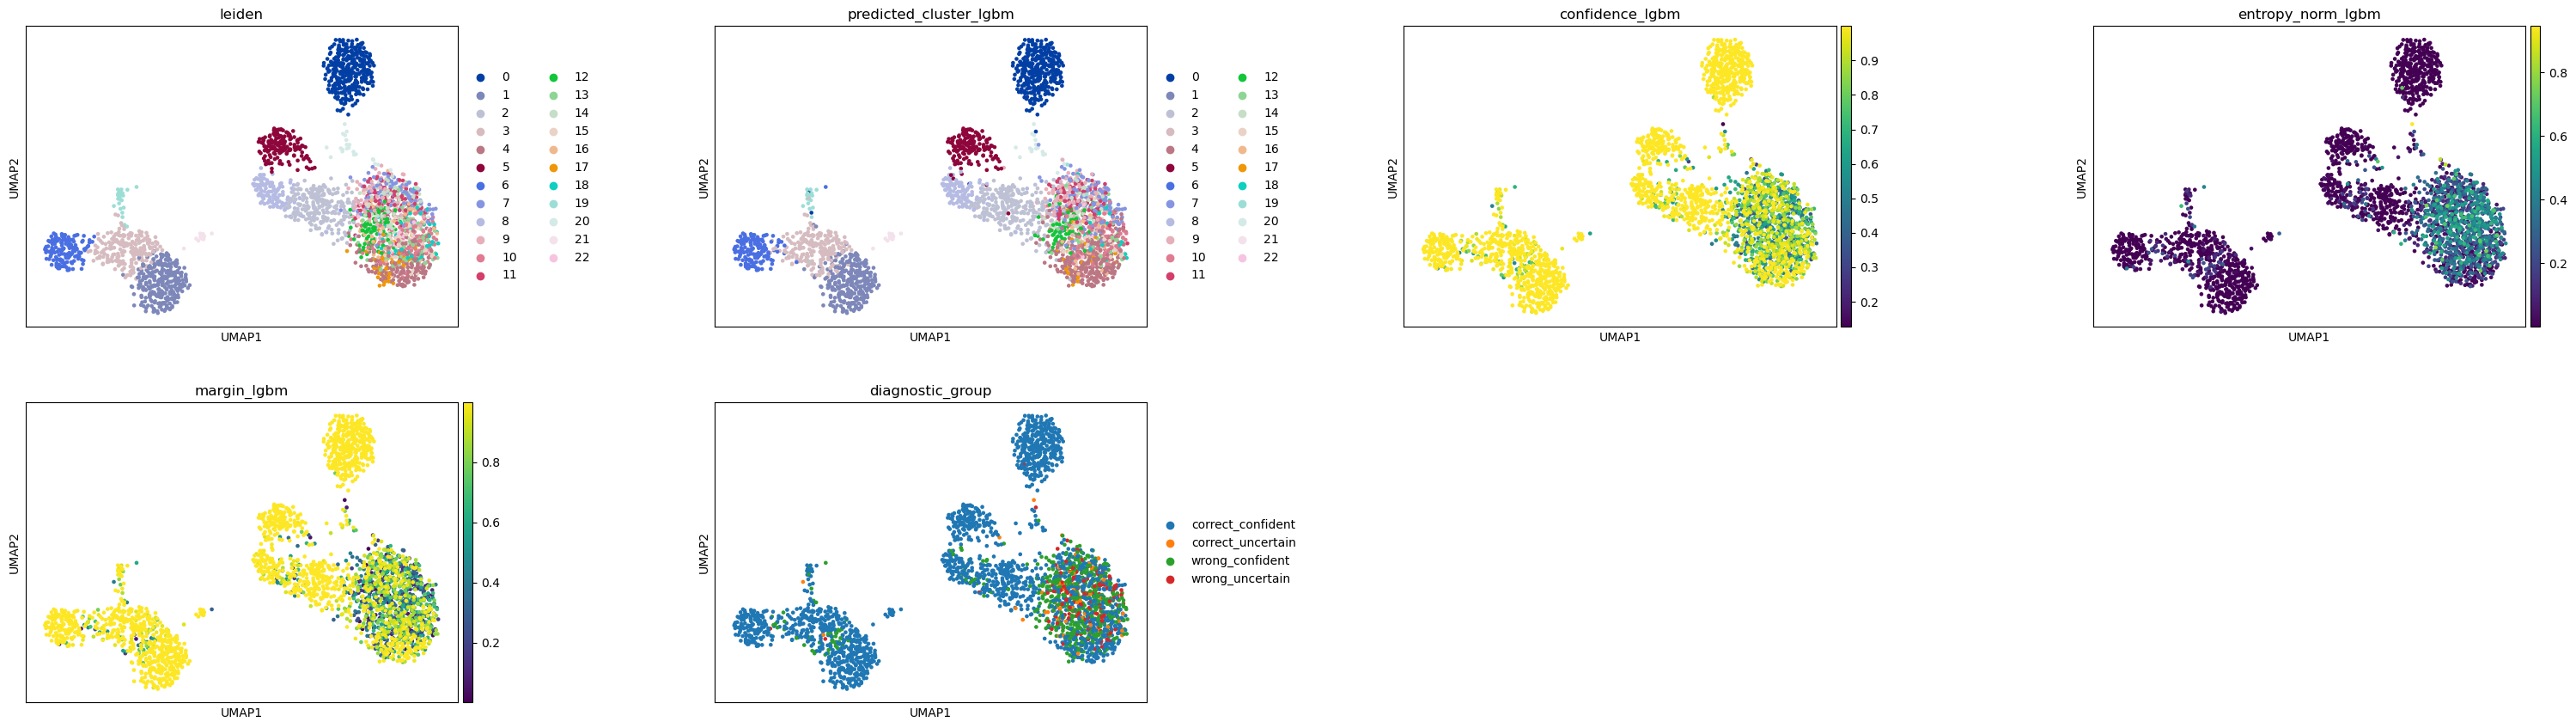

In [32]:
adata.obs["diagnostic_group"] = obs["diagnostic_group"]

sc.pl.umap(
    adata,
    color=[
        "leiden",
        "predicted_cluster_lgbm",
        "confidence_lgbm",
        "entropy_norm_lgbm",
        "margin_lgbm",
        "diagnostic_group",
    ],
    wspace=0.45,
)


## Simple wrong-or-tail UMAP

This plot keeps Leiden clusters as a faint background and overlays one marker for any cell that is either wrongly predicted or in any uncertainty tail.


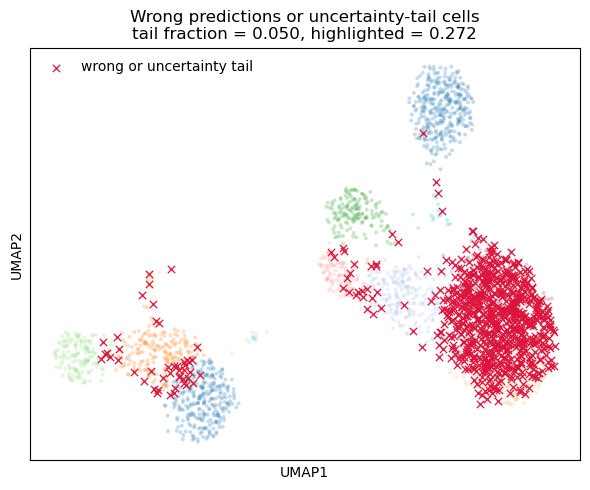

WindowsPath('d:/personal_projects/scRNAseq_lightGBM/results/figures/confidence_diagnostics/single_run_wrong_or_tail_umap.png')

In [33]:
# Uses masks from the earlier overlap section:
# wrong_mask, low_margin_mask, high_entropy_mask, low_conf_mask
simple_tail_mask = low_margin_mask | high_entropy_mask | low_conf_mask
simple_highlight_mask = np.asarray(wrong_mask | simple_tail_mask)

coords = adata.obsm["X_umap"]
leiden_codes = adata.obs["leiden"].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=leiden_codes,
    cmap="tab20",
    s=8,
    alpha=0.25,
    linewidths=0,
)
ax.scatter(
    coords[simple_highlight_mask, 0],
    coords[simple_highlight_mask, 1],
    c="crimson",
    marker="x",
    s=28,
    linewidths=0.9,
    label="wrong or uncertainty tail",
)
ax.set_title(
    "Wrong predictions or uncertainty-tail cells\n"
    f"tail fraction = {tail_fraction:.3f}, highlighted = {simple_highlight_mask.mean():.3f}"
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="best", frameon=False)
fig.tight_layout()

single_plot_dir = project_root / "results/figures/confidence_diagnostics"
single_plot_dir.mkdir(parents=True, exist_ok=True)
single_plot_path = single_plot_dir / "single_run_wrong_or_tail_umap.png"
fig.savefig(single_plot_path, dpi=200, bbox_inches="tight")
plt.show()

single_plot_path


## Batch overlap across datasets and resolutions

For each archived run, this uses the wrong-prediction fraction as the uncertainty-tail fraction. For example, if 2% of cells are wrong predictions, the uncertainty sets are the lowest 2% margin, highest 2% normalized entropy, and lowest 2% confidence.


In [34]:
import re

batch_archive_dir = project_root / "data/processed/archive"
batch_output_dir = project_root / "results/tables/confidence_diagnostics"
batch_output_dir.mkdir(parents=True, exist_ok=True)

expected_datasets = ["pbmc3k", "pbmc68k_reduced", "paul15"]
expected_resolutions = [0.5, 1.0, 1.5, 2.0, 2.5]

def parse_archived_run_name(path):
    stem = path.stem
    m = re.match(r"(.+)_res_([0-9]+(?:[.p][0-9]+)?)$", stem)
    if m is None:
        raise ValueError(f"Unexpected filename: {stem}")
    dataset = m.group(1)
    resolution = float(m.group(2).replace("p", "."))
    return dataset, resolution

archive_records = []
for path in sorted(batch_archive_dir.glob("*.h5ad")):
    dataset, resolution = parse_archived_run_name(path)
    if dataset in expected_datasets and resolution in expected_resolutions:
        archive_records.append({
            "path": path,
            "dataset": dataset,
            "resolution": resolution,
            "mtime": path.stat().st_mtime,
        })

batch_runs_df = (
    pd.DataFrame(archive_records)
    .sort_values(["dataset", "resolution", "mtime"])
    .drop_duplicates(["dataset", "resolution"], keep="last")
    .sort_values(["dataset", "resolution"])
    .reset_index(drop=True)
)

batch_runs_df


,path,dataset,resolution,mtime
0,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,0.5,1.777562e+09
1,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,1.0,1.777562e+09
2,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,1.5,1.777562e+09
3,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,2.0,1.777562e+09
4,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,2.5,1.777563e+09
5,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,0.5,1.777561e+09
6,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,1.0,1.777561e+09
7,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,1.5,1.777562e+09
8,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,2.0,1.777562e+09
9,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,2.5,1.777562e+09


In [41]:
def compute_overlap_summary_for_run(path, dataset, resolution):
    adata_run = sc.read_h5ad(path)
    obs_run = adata_run.obs.copy()

    if "entropy_norm_lgbm" not in obs_run:
        n_classes = obs_run["leiden"].astype(str).nunique()
        obs_run["entropy_norm_lgbm"] = obs_run["entropy_lgbm"] / np.log(n_classes)

    wrong_mask = (
        obs_run["predicted_cluster_lgbm"].astype(str)
        != obs_run["leiden"].astype(str)
    )

    n_cells = adata_run.n_obs
    n_wrong = int(wrong_mask.sum())
    wrong_fraction = n_wrong / n_cells
    tail_fraction = min(wrong_fraction * 2, 0.5)

    if n_wrong == 0:
        low_margin_mask = pd.Series(False, index=obs_run.index)
        high_entropy_mask = pd.Series(False, index=obs_run.index)
        low_conf_mask = pd.Series(False, index=obs_run.index)
        low_margin_cutoff = np.nan
        high_entropy_cutoff = np.nan
        low_conf_cutoff = np.nan
    else:
        low_margin_cutoff = obs_run["margin_lgbm"].quantile(tail_fraction)
        high_entropy_cutoff = obs_run["entropy_norm_lgbm"].quantile(1 - tail_fraction)
        low_conf_cutoff = obs_run["confidence_lgbm"].quantile(tail_fraction)

        low_margin_mask = obs_run["margin_lgbm"] <= low_margin_cutoff
        high_entropy_mask = obs_run["entropy_norm_lgbm"] >= high_entropy_cutoff
        low_conf_mask = obs_run["confidence_lgbm"] <= low_conf_cutoff

    any_uncertainty_mask = low_margin_mask | high_entropy_mask | low_conf_mask
    all_three_uncertainty_mask = low_margin_mask & high_entropy_mask & low_conf_mask

    group_masks = {
        "wrong_prediction": wrong_mask,
        "low_margin_tail": low_margin_mask,
        "high_entropy_tail": high_entropy_mask,
        "low_confidence_tail": low_conf_mask,
        "any_uncertainty_tail": any_uncertainty_mask,
        "all_three_uncertainty_tail": all_three_uncertainty_mask,
        "wrong & low_margin": wrong_mask & low_margin_mask,
        "wrong & high_entropy": wrong_mask & high_entropy_mask,
        "wrong & low_confidence": wrong_mask & low_conf_mask,
        "wrong & any_uncertainty": wrong_mask & any_uncertainty_mask,
        "wrong & all_three_uncertainty": wrong_mask & all_three_uncertainty_mask,
        "low_margin & high_entropy": low_margin_mask & high_entropy_mask,
        "low_margin & low_confidence": low_margin_mask & low_conf_mask,
        "high_entropy & low_confidence": high_entropy_mask & low_conf_mask,
    }

    rows = []
    for group, mask in group_masks.items():
        n_group = int(mask.sum())
        rows.append({
            "dataset": dataset,
            "resolution": resolution,
            "path": str(path),
            "n_cells": n_cells,
            "n_wrong": n_wrong,
            "wrong_fraction": wrong_fraction,
            "tail_fraction": tail_fraction,
            "low_margin_cutoff": low_margin_cutoff,
            "high_entropy_cutoff": high_entropy_cutoff,
            "low_confidence_cutoff": low_conf_cutoff,
            "group": group,
            "n_group_cells": n_group,
            "fraction_of_cells": n_group / n_cells,
            "fraction_of_wrong": n_group / n_wrong if n_wrong else np.nan,
        })

    return pd.DataFrame(rows)

all_overlap_summaries = []

for _, run in batch_runs_df.iterrows():
    summary = compute_overlap_summary_for_run(
        path=run["path"],
        dataset=run["dataset"],
        resolution=run["resolution"],
    )
    all_overlap_summaries.append(summary)

overlap_summary_all = pd.concat(all_overlap_summaries, ignore_index=True)

overlap_summary_path = batch_output_dir / "overlap_summary_wrong_fraction_x2.csv"
overlap_summary_all.to_csv(overlap_summary_path, index=False)

overlap_summary_path


WindowsPath('d:/personal_projects/scRNAseq_lightGBM/results/tables/confidence_diagnostics/overlap_summary_wrong_fraction_x2.csv')

In [36]:
key_overlap = overlap_summary_all[
    overlap_summary_all["group"].isin([
        "wrong & any_uncertainty",
        "wrong & all_three_uncertainty",
    ])
].copy()

key_overlap = key_overlap[
    [
        "dataset",
        "resolution",
        "n_cells",
        "n_wrong",
        "wrong_fraction",
        "group",
        "n_group_cells",
        "fraction_of_wrong",
        "fraction_of_cells",
    ]
].sort_values(["dataset", "resolution", "group"])

key_overlap


,dataset,resolution,n_cells,n_wrong,wrong_fraction,group,n_group_cells,fraction_of_wrong,fraction_of_cells
10,paul15,0.5,2730,149,0.054579,wrong & all_three_uncertainty,103,0.691275,0.037729
9,paul15,0.5,2730,149,0.054579,wrong & any_uncertainty,103,0.691275,0.037729
24,paul15,1.0,2730,266,0.097436,wrong & all_three_uncertainty,201,0.755639,0.073626
23,paul15,1.0,2730,266,0.097436,wrong & any_uncertainty,207,0.778195,0.075824
38,paul15,1.5,2730,339,0.124176,wrong & all_three_uncertainty,252,0.743363,0.092308
37,paul15,1.5,2730,339,0.124176,wrong & any_uncertainty,257,0.758112,0.094139
52,paul15,2.0,2730,426,0.156044,wrong & all_three_uncertainty,323,0.758216,0.118315
51,paul15,2.0,2730,426,0.156044,wrong & any_uncertainty,326,0.765258,0.119414
66,paul15,2.5,2730,452,0.165568,wrong & all_three_uncertainty,353,0.780973,0.129304
65,paul15,2.5,2730,452,0.165568,wrong & any_uncertainty,361,0.798673,0.132234


## Batch wrong-or-tail UMAPs

This saves one UMAP per archived dataset/resolution run. Background cells show faint Leiden clusters. Red `x` markers indicate cells that are either wrongly predicted or in any uncertainty tail. The tail fraction is `min(wrong_fraction * 2, 0.5)` for each run.


In [39]:
batch_umap_dir = project_root / "results/figures/confidence_diagnostics/wrong_or_tail_umaps"
batch_umap_dir.mkdir(parents=True, exist_ok=True)

def save_wrong_or_tail_umap_for_run(path, dataset, resolution):
    adata_run = sc.read_h5ad(path)
    obs_run = adata_run.obs.copy()

    if "X_umap" not in adata_run.obsm:
        raise KeyError(f"X_umap not found in {path}")

    if "entropy_norm_lgbm" not in obs_run:
        n_classes = obs_run["leiden"].astype(str).nunique()
        obs_run["entropy_norm_lgbm"] = obs_run["entropy_lgbm"] / np.log(n_classes)

    wrong_mask = (
        obs_run["predicted_cluster_lgbm"].astype(str)
        != obs_run["leiden"].astype(str)
    )

    n_wrong = int(wrong_mask.sum())
    wrong_fraction = n_wrong / adata_run.n_obs
    tail_fraction = min(wrong_fraction , 0.5)

    if n_wrong == 0:
        tail_mask = pd.Series(False, index=obs_run.index)
    else:
        low_margin_cutoff = obs_run["margin_lgbm"].quantile(tail_fraction)
        high_entropy_cutoff = obs_run["entropy_norm_lgbm"].quantile(1 - tail_fraction)
        low_conf_cutoff = obs_run["confidence_lgbm"].quantile(tail_fraction)

        tail_mask = (
            (obs_run["margin_lgbm"] <= low_margin_cutoff)
            | (obs_run["entropy_norm_lgbm"] >= high_entropy_cutoff)
            | (obs_run["confidence_lgbm"] <= low_conf_cutoff)
        )

    highlight_mask = np.asarray(wrong_mask | tail_mask)
    coords = adata_run.obsm["X_umap"]
    leiden_codes = obs_run["leiden"].astype("category").cat.codes

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=leiden_codes,
        cmap="tab20",
        s=8,
        alpha=0.25,
        linewidths=0,
    )
    ax.scatter(
        coords[highlight_mask, 0],
        coords[highlight_mask, 1],
        c="crimson",
        marker="x",
        s=28,
        linewidths=0.9,
        label="wrong or uncertainty tail",
    )
    ax.set_title(
        f"{dataset} res={resolution:g}\n"
        f"wrong={wrong_fraction:.3f}, tail={tail_fraction:.3f}, highlighted={highlight_mask.mean():.3f}"
    )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()

    resolution_str = str(resolution).replace(".", "p")
    out_path = batch_umap_dir / f"{dataset}_res_{resolution_str}_wrong_or_tail_umap.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return {
        "dataset": dataset,
        "resolution": resolution,
        "n_cells": adata_run.n_obs,
        "n_wrong": n_wrong,
        "wrong_fraction": wrong_fraction,
        "tail_fraction": tail_fraction,
        "n_highlighted": int(highlight_mask.sum()),
        "highlighted_fraction": float(highlight_mask.mean()),
        "plot_path": out_path,
    }

plot_records = []
for _, run in batch_runs_df.iterrows():
    plot_records.append(
        save_wrong_or_tail_umap_for_run(
            path=run["path"],
            dataset=run["dataset"],
            resolution=run["resolution"],
        )
    )

batch_umap_df = pd.DataFrame(plot_records)
batch_umap_summary_path = batch_umap_dir / "wrong_or_tail_umap_summary.csv"
batch_umap_df.to_csv(batch_umap_summary_path, index=False)

batch_umap_df


,dataset,resolution,n_cells,n_wrong,wrong_fraction,tail_fraction,n_highlighted,highlighted_fraction,plot_path
0,paul15,0.5,2730,149,0.054579,0.054579,234,0.085714,d:\personal_projects\scRNAseq_lightGBM\results...
1,paul15,1.0,2730,266,0.097436,0.097436,414,0.151648,d:\personal_projects\scRNAseq_lightGBM\results...
2,paul15,1.5,2730,339,0.124176,0.124176,536,0.196337,d:\personal_projects\scRNAseq_lightGBM\results...
3,paul15,2.0,2730,426,0.156044,0.156044,660,0.241758,d:\personal_projects\scRNAseq_lightGBM\results...
4,paul15,2.5,2730,452,0.165568,0.165568,698,0.255678,d:\personal_projects\scRNAseq_lightGBM\results...
5,pbmc3k,0.5,2700,73,0.027037,0.027037,116,0.042963,d:\personal_projects\scRNAseq_lightGBM\results...
6,pbmc3k,1.0,2700,195,0.072222,0.072222,299,0.110741,d:\personal_projects\scRNAseq_lightGBM\results...
7,pbmc3k,1.5,2700,228,0.084444,0.084444,359,0.132963,d:\personal_projects\scRNAseq_lightGBM\results...
8,pbmc3k,2.0,2700,496,0.183704,0.183704,740,0.274074,d:\personal_projects\scRNAseq_lightGBM\results...
9,pbmc3k,2.5,2700,674,0.249630,0.249630,935,0.346296,d:\personal_projects\scRNAseq_lightGBM\results...


## 1x vs 2x uncertainty-tail capture

This plot compares how many wrong predictions are captured by uncertainty tails. The 1x tail flags the same fraction of cells as the wrong-prediction rate; the 2x tail flags twice that fraction.


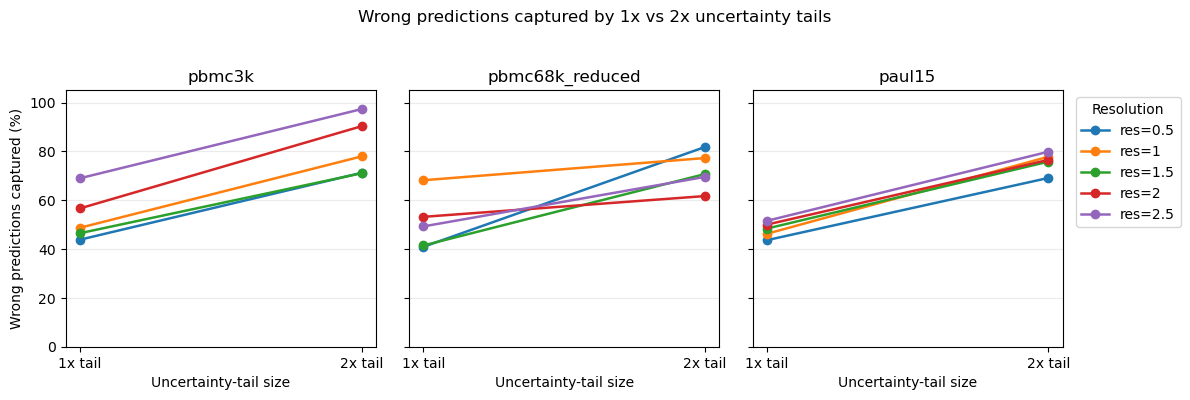

,dataset,resolution,tail_label,n_wrong,n_group_cells,fraction_of_wrong,percent_wrong_captured
0,paul15,0.5,1x tail,149,65,0.436242,43.624161
15,paul15,0.5,2x tail,149,103,0.691275,69.127517
1,paul15,1.0,1x tail,266,123,0.462406,46.240602
16,paul15,1.0,2x tail,266,207,0.778195,77.819549
2,paul15,1.5,1x tail,339,164,0.483776,48.377581
17,paul15,1.5,2x tail,339,257,0.758112,75.811209
3,paul15,2.0,1x tail,426,213,0.500000,50.000000
18,paul15,2.0,2x tail,426,326,0.765258,76.525822
4,paul15,2.5,1x tail,452,233,0.515487,51.548673
19,paul15,2.5,2x tail,452,361,0.798673,79.867257


In [42]:
comparison_dir = project_root / "results/figures/confidence_diagnostics"
comparison_dir.mkdir(parents=True, exist_ok=True)

summary_dir = project_root / "results/tables/confidence_diagnostics"
files = {
    "1x tail": summary_dir / "overlap_summary_wrong_fraction.csv",
    "2x tail": summary_dir / "overlap_summary_wrong_fraction_x2.csv",
}

capture_frames = []
for tail_label, path in files.items():
    df = pd.read_csv(path)
    key = df[df["group"] == "wrong & any_uncertainty"].copy()
    key["tail_label"] = tail_label
    capture_frames.append(key)

capture_df = pd.concat(capture_frames, ignore_index=True)
capture_df["percent_wrong_captured"] = 100 * capture_df["fraction_of_wrong"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
datasets = ["pbmc3k", "pbmc68k_reduced", "paul15"]

for ax, dataset in zip(axes, datasets):
    subset = capture_df[capture_df["dataset"] == dataset]
    for resolution, resolution_df in subset.groupby("resolution"):
        resolution_df = resolution_df.set_index("tail_label").loc[["1x tail", "2x tail"]].reset_index()
        ax.plot(
            resolution_df["tail_label"],
            resolution_df["percent_wrong_captured"],
            marker="o",
            linewidth=1.8,
            label=f"res={resolution:g}",
        )

    ax.set_title(dataset)
    ax.set_xlabel("Uncertainty-tail size")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, 105)

axes[0].set_ylabel("Wrong predictions captured (%)")
axes[-1].legend(title="Resolution", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Wrong predictions captured by 1x vs 2x uncertainty tails", y=1.04)
fig.tight_layout()

capture_plot_path = comparison_dir / "wrong_prediction_capture_1x_vs_2x.png"
fig.savefig(capture_plot_path, dpi=200, bbox_inches="tight")
plt.show()

capture_df[
    [
        "dataset",
        "resolution",
        "tail_label",
        "n_wrong",
        "n_group_cells",
        "fraction_of_wrong",
        "percent_wrong_captured",
    ]
].sort_values(["dataset", "resolution", "tail_label"])
